In [13]:
import seaborn as sns
import sklearn

In [14]:
import os

# Check how many images in each folder
base_dir="archive/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset"
class_names = ['Bengin cases', 'Malignant cases', 'Normal cases']
for class_name in class_names:
    class_folder = os.path.join(base_dir, class_name);
    files = [f for f in os.listdir(class_folder)]
    print(len(files))

120
561
416


In [15]:
import shutil
import random
from PIL import Image, ImageEnhance

# Reset output dir if already present
output_dir = "balanced_dataset"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

# Define target count for each class after augmentation
target_count = 600
img_size = (512, 512)

# Define random transformations
def get_random_transform():
    options = [
        lambda img: img.transpose(Image.FLIP_LEFT_RIGHT),
        lambda img: img.transpose(Image.FLIP_TOP_BOTTOM),
        lambda img: img.rotate(random.uniform(-25, 25)),
        lambda img: ImageEnhance.Contrast(img).enhance(random.uniform(1.2, 1.8)),
        lambda img: ImageEnhance.Color(img).enhance(random.uniform(1.2, 2.0)),
        lambda img: ImageEnhance.Sharpness(img).enhance(random.uniform(1.5, 2.5))
    ]
    return random.choice(options)

def augment_and_save(class_name, target_count):
    class_src = os.path.join(base_dir, class_name)
    class_dst = os.path.join(output_dir, class_name)
    os.makedirs(class_dst)

    images = [f for f in os.listdir(class_src)]
    original_count = len(images)

    # Copy images to output_dir
    for img in images:
        shutil.copy(os.path.join(class_src, img), os.path.join(class_dst, img))

    # Check if original_count < target_count
    extra_needed = target_count - original_count
    if extra_needed <= 0:
        return

    print(f"Need to generate {extra_needed} new images for {class_name}")

    for i in range(extra_needed):
        img_name = random.choice(images)
        try:
            with Image.open(os.path.join(class_src, img_name)) as img:
                img = img.convert('RGB').resize(img_size)
                transformed_img = get_random_transform()(img)
                save_name = f"aug{i}_{img_name}"
                transformed_img.save(os.path.join(class_dst, save_name))
        except Exception as err:
            print(f"Error while augmenting: {err}")

for class_name in class_names:
    augment_and_save(class_name, target_count)

print("Augmentation complete for all classes!")

Need to generate 480 new images for Bengin cases
Need to generate 39 new images for Malignant cases
Need to generate 184 new images for Normal cases
Augmentation complete for all classes!


In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # VGG expects 224x224
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # ImageNet means
                         [0.229, 0.224, 0.225])  # ImageNet std
])

dataset = datasets.ImageFolder(root="balanced_dataset", transform=data_transforms)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

VGG16

In [2]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.vgg16(pretrained=True)

# Freeze all layers except classifier
for param in model.features.parameters():
    param.requires_grad = False

# Replace the classifier (VGG16 has 4096 → 1000 classes by default)
model.classifier[6] = nn.Linear(4096, 3)  # 3 classes: Bengin, Malignant, Normal

model = model.to(device)

/Users/proshadmohonto/Desktop/defense_work/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/proshadmohonto/Desktop/defense_work/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001)

num_epochs = 10
vgg_train_losses = []
vgg_train_accuracies = []
vgg_val_losses = []
vgg_val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    vgg_train_losses.append(epoch_loss)
    vgg_train_accuracies.append(epoch_acc)

    # Validation loop
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    vgg_val_losses.append(val_loss / len(val_loader))
    vgg_val_accuracies.append(val_correct / val_total)

    print(f"Epoch {epoch+1}, Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Loss: {vgg_val_losses[-1]:.4f}, Val Acc: {vgg_val_accuracies[-1]:.4f}")

Epoch 1, Train Loss: 0.8771, Train Acc: 0.5681, Val Loss: 0.6217, Val Acc: 0.7611
Epoch 2, Train Loss: 0.5590, Train Acc: 0.7667, Val Loss: 0.4702, Val Acc: 0.8028
Epoch 3, Train Loss: 0.4187, Train Acc: 0.8354, Val Loss: 0.3701, Val Acc: 0.8639
Epoch 4, Train Loss: 0.3276, Train Acc: 0.8750, Val Loss: 0.3091, Val Acc: 0.9028
Epoch 5, Train Loss: 0.2571, Train Acc: 0.9035, Val Loss: 0.2500, Val Acc: 0.9028
Epoch 6, Train Loss: 0.2020, Train Acc: 0.9333, Val Loss: 0.2182, Val Acc: 0.9111
Epoch 7, Train Loss: 0.1555, Train Acc: 0.9500, Val Loss: 0.1743, Val Acc: 0.9250
Epoch 8, Train Loss: 0.1198, Train Acc: 0.9646, Val Loss: 0.1537, Val Acc: 0.9361
Epoch 9, Train Loss: 0.0874, Train Acc: 0.9792, Val Loss: 0.1286, Val Acc: 0.9389
Epoch 10, Train Loss: 0.0688, Train Acc: 0.9840, Val Loss: 0.1136, Val Acc: 0.9444


VGG16 Evaluation Metrics:
Accuracy: 0.9444
Precision: 0.9444
Recall (Sensitivity): 0.9444
Specificity: 0.9435
F1 Score: 0.9442
AUC: 0.9956
MCC: 0.9168


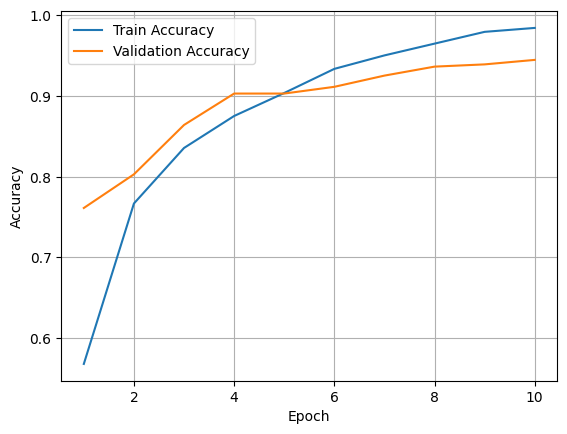

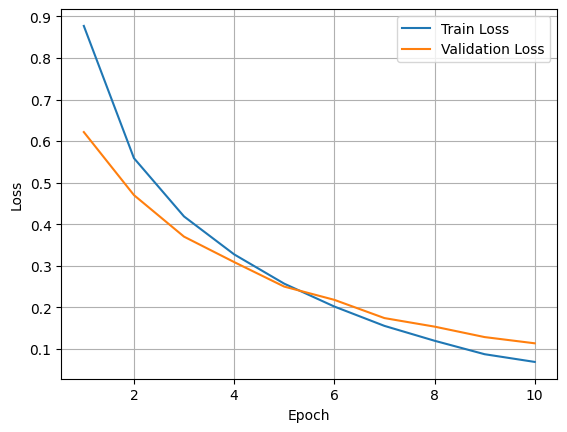

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []
all_probs = []  # To store probabilities for AUC calculation
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        # Get probabilities (softmax of outputs)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)  # Probabilities for each class

# Compute metrics
sklearn_accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Compute confusion matrix for sensitivity and specificity
cm = confusion_matrix(y_true, y_pred)
tn = cm.diagonal()  # True negatives are the diagonal elements
fp = cm.sum(axis=0) - tn  # False positives
fn = cm.sum(axis=1) - tn  # False negatives
tp = cm.diagonal()  # True positives

sensitivity = tp / (tp + fn)  # Also known as recall
specificity = tn / (tn + fp)

# For multiclass, we'll take weighted averages
sensitivity = np.mean(sensitivity)
specificity = np.mean(specificity)

# Compute AUC (one-vs-rest approach for multiclass)
try:
    auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='weighted')
except:
    auc = float('nan')  # In case of error (e.g., only one class present)

# Compute Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_true, y_pred)

# Save to dictionary
vgg_metrics = {
    'Accuracy': round(sklearn_accuracy, 4),
    'Precision': round(precision, 4),
    'Recall (Sensitivity)': round(recall, 4),
    'Specificity': round(specificity, 4),
    'F1 Score': round(f1, 4),
    'AUC': round(auc, 4),
    'MCC': round(mcc, 4)
}

print("VGG16 Evaluation Metrics:")
for key, value in vgg_metrics.items():
    print(f"{key}: {value}")

# Accuracy plot
plt.plot(range(1, num_epochs+1), vgg_train_accuracies, label='Train Accuracy')
plt.plot(range(1, num_epochs+1), vgg_val_accuracies, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("")
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.plot(range(1, num_epochs+1), vgg_train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), vgg_val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("")
plt.legend()
plt.grid(True)
plt.show()

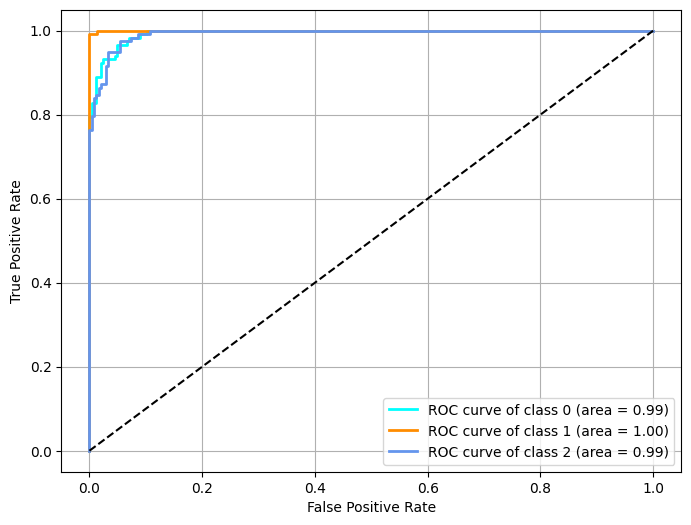


Updated VGG16 Evaluation Metrics:
Accuracy: 0.9444
Precision: 0.9444
Recall (Sensitivity): 0.9444
Specificity: 0.9435
F1 Score: 0.9442
AUC: 0.9956
MCC: 0.9168
AUC (Macro): 0.9958
AUC (Micro): 0.9965


In [7]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle

# Assuming you have these variables from previous code:
# y_true - true labels
# y_probs - predicted probabilities for each class
# n_classes - number of classes in your classification problem

# Binarize the output for multiclass ROC
n_classes = y_probs.shape[1]
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 
                'purple', 'pink', 'brown', 'gray', 'olive'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.title("")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Update your metrics dictionary with AUC values
vgg_metrics['AUC (Macro)'] = round(roc_auc["macro"], 4)
vgg_metrics['AUC (Micro)'] = round(roc_auc["micro"], 4)

print("\nUpdated VGG16 Evaluation Metrics:")
for key, value in vgg_metrics.items():
    print(f"{key}: {value}")

In [8]:
categories = ["Bengin cases", "Malignant cases", "Normal cases"]


Confusion Matrix:


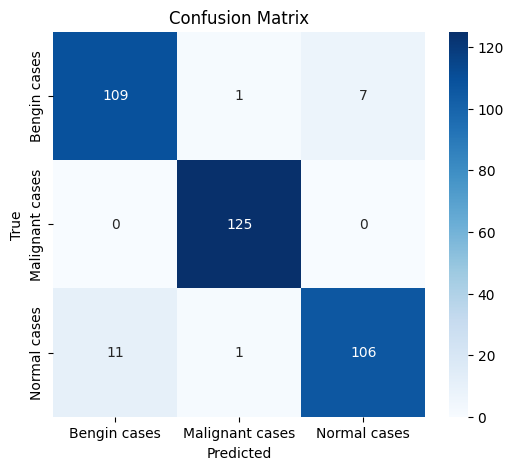

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

categories = ["Bengin cases", "Malignant cases", "Normal cases"]

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories,
            yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


ResNet50

In [24]:


import torchvision.models as models
import torch.nn as nn

# Load pretrained ResNet50
resnet50 = models.resnet50(pretrained=True)

num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_ftrs, 3)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet50 = resnet50.to(device)



/Users/proshadmohonto/Desktop/defense_work/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/proshadmohonto/Desktop/defense_work/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [25]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet50.parameters(), lr=0.01)

# Training loop
epochs = 10
rn_train_losses = []
rn_train_accuracies = []
rn_val_losses = []
rn_val_accuracies = []

for epoch in range(epochs):
    resnet50.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    rn_train_losses.append(epoch_loss)
    rn_train_accuracies.append(epoch_acc)

    # Validation loop
    resnet50.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet50(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    rn_val_losses.append(val_loss / len(val_loader))
    rn_val_accuracies.append(val_correct / val_total)

    print(f"Epoch {epoch+1}, Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Loss: {rn_val_losses[-1]:.4f}, Val Acc: {rn_val_accuracies[-1]:.4f}")

Epoch 1, Train Loss: 1.5740, Train Acc: 0.3514, Val Loss: 1.2782, Val Acc: 0.3861
Epoch 2, Train Loss: 0.9852, Train Acc: 0.4868, Val Loss: 7.6845, Val Acc: 0.3667
Epoch 3, Train Loss: 0.9149, Train Acc: 0.5681, Val Loss: 3.1464, Val Acc: 0.2861
Epoch 4, Train Loss: 0.7111, Train Acc: 0.6549, Val Loss: 1.2180, Val Acc: 0.4389
Epoch 5, Train Loss: 0.6407, Train Acc: 0.7063, Val Loss: 0.6423, Val Acc: 0.6750
Epoch 6, Train Loss: 0.5515, Train Acc: 0.7375, Val Loss: 0.8346, Val Acc: 0.6472
Epoch 7, Train Loss: 0.4839, Train Acc: 0.7937, Val Loss: 3.5430, Val Acc: 0.3361
Epoch 8, Train Loss: 0.5139, Train Acc: 0.7847, Val Loss: 2.2678, Val Acc: 0.5111
Epoch 9, Train Loss: 0.3913, Train Acc: 0.8438, Val Loss: 2.9172, Val Acc: 0.5056
Epoch 10, Train Loss: 0.3375, Train Acc: 0.8708, Val Loss: 1.6780, Val Acc: 0.6056



ResNet50 Evaluation Metrics:
Accuracy: 0.6056
Precision: 0.7118
Recall (Sensitivity): 0.6056
Specificity: 0.7168
F1 Score: 0.5241
AUC: 0.9282
MCC: 0.4672


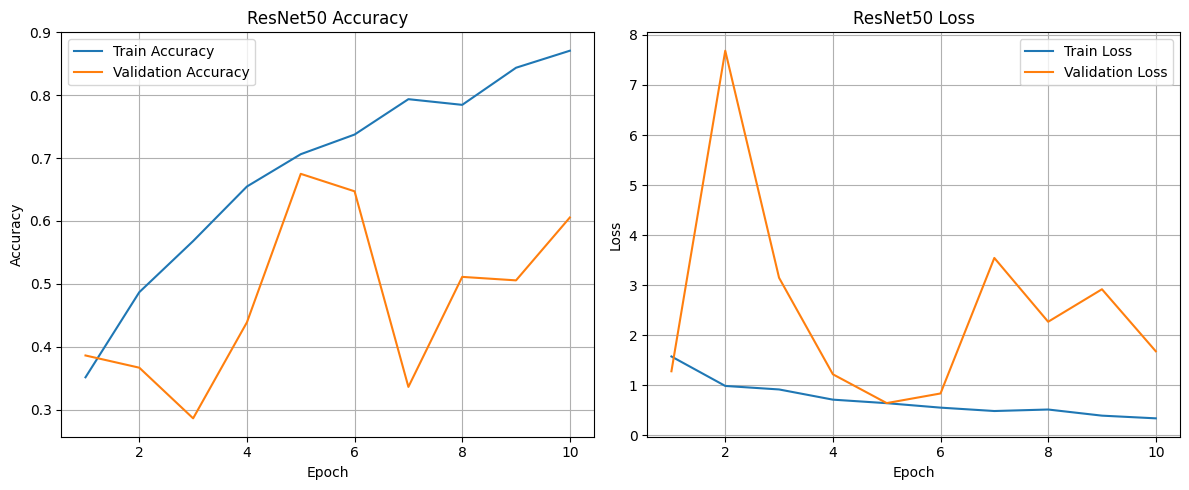

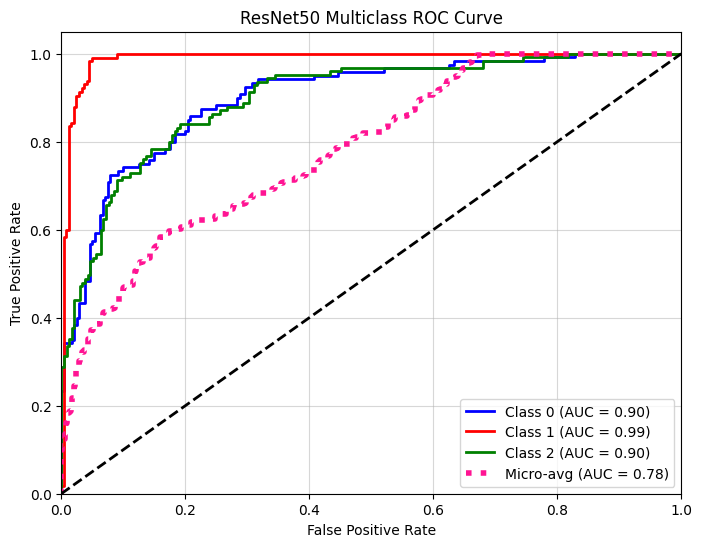

In [26]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_curve, auc, matthews_corrcoef, 
                            confusion_matrix, roc_auc_score)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

epochs = 10

resnet50.eval()
all_preds = []
all_labels = []
all_probs = []  # Store probabilities for AUC calculation
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet50(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)  # Get probabilities
        _, preds = torch.max(outputs, 1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn = np.diag(cm)  # True negatives
fp = cm.sum(axis=0) - tn  # False positives
fn = cm.sum(axis=1) - tn  # False negatives
tp = np.diag(cm)  # True positives

# Compute metrics
sensitivity = tp / (tp + fn)  # Recall per class
specificity = tn / (tn + fp)  # Specificity per class

# Multiclass AUC (One-vs-Rest)
try:
    auc_score = roc_auc_score(y_true, y_probs, multi_class='ovr', average='weighted')
except:
    auc_score = float('nan')

# Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_true, y_pred)

resnet_metrics = {
    'Accuracy': round(accuracy_score(y_true, y_pred), 4),
    'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
    'Recall (Sensitivity)': round(recall_score(y_true, y_pred, average='weighted'), 4),
    'Specificity': round(np.mean(specificity), 4),
    'F1 Score': round(f1_score(y_true, y_pred, average='weighted'), 4),
    'AUC': round(auc_score, 4),
    'MCC': round(mcc, 4)
}

# Print metrics
print("\nResNet50 Evaluation Metrics:")
for key, value in resnet_metrics.items():
    print(f"{key}: {value}")

# Plot training curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), rn_train_accuracies, label='Train Accuracy')
plt.plot(range(1, epochs+1), rn_val_accuracies, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), rn_train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), rn_val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ROC Curve (Multiclass)
n_classes = y_probs.shape[1]
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']  # Adjust colors based on your classes
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Class {0} (AUC = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot(fpr["micro"], tpr["micro"],
         label='Micro-avg (AUC = {0:0.2f})'.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ResNet50 Multiclass ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.5)
plt.show()


Confusion Matrix:


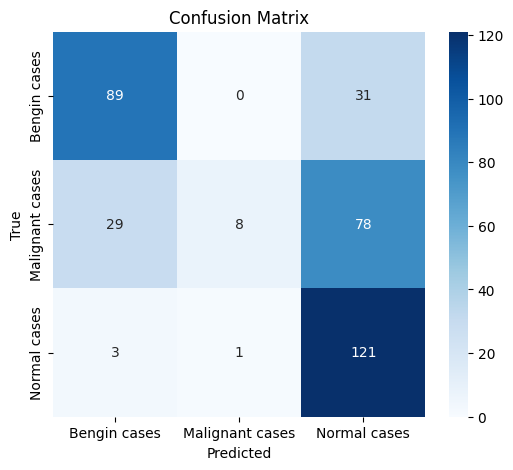

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

categories = ["Bengin cases", "Malignant cases", "Normal cases"]

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories,
            yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()



MobileNet V2¶


Found 1440 images belonging to 3 classes.
Found 360 images belonging to 3 classes.
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 448ms/step - accuracy: 0.4611 - loss: 1.1085 - val_accuracy: 0.5556 - val_loss: 0.8914
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 386ms/step - accuracy: 0.5528 - loss: 0.9396 - val_accuracy: 0.6528 - val_loss: 0.8013
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 386ms/step - accuracy: 0.6104 - loss: 0.8093 - val_accuracy: 0.6333 - val_loss: 0.7493
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 382ms/step - accuracy: 0.6493 - loss: 0.7497 - val_accuracy: 0.6750 - val_loss: 0.7055
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 388ms/step - accuracy: 0.6722 - loss: 0.6877 - val_accuracy: 0.6667 - val_loss: 0.6804
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 385ms/step - accuracy: 0.6701 - loss: 0.6796 - val_accuracy: 0.6889 - val_loss: 0.6458
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 424ms/step - accuracy: 0.7167 - loss: 0.6220 - val_accuracy: 0.7139 - val_loss: 0.6266
Epoch 8/10
45/

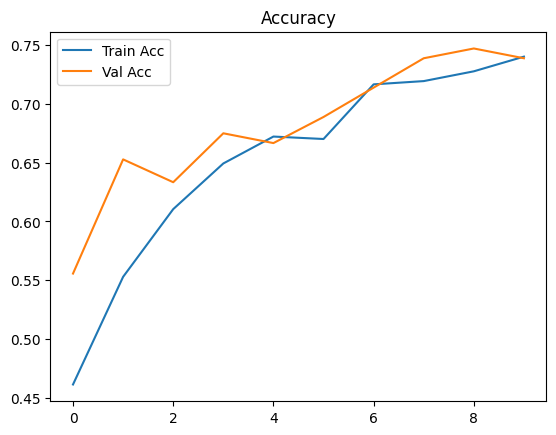

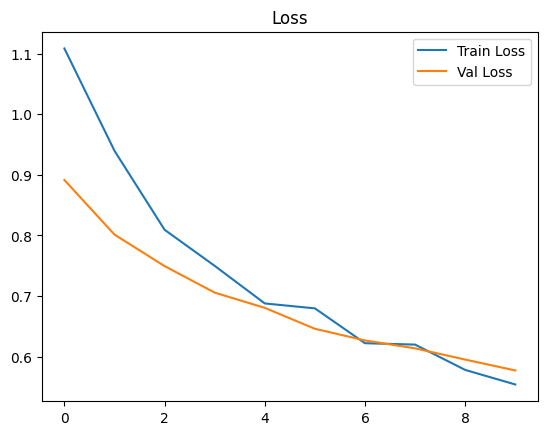

In [3]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, matthews_corrcoef

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ---- Your existing code ----
data_dir = "balanced_dataset"
img_size = (224, 224)
batch_size = 32
epochs = 10

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_gen, validation_data=val_gen, epochs=epochs)

# ---- Predictions ----
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

# ---- Confusion matrix ----
cm = confusion_matrix(y_true, y_pred)

# ---- Specificity per class ----
specificity = []
for i in range(len(cm)):
    tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
    fp = np.sum(cm[:, i]) - cm[i, i]
    specificity.append(tn / (tn + fp))
specificity_mean = np.mean(specificity)

# ---- AUC ----
# One-hot encode y_true for multi-class AUC
from sklearn.preprocessing import label_binarize
y_true_bin = label_binarize(y_true, classes=np.arange(train_gen.num_classes))
auc_score = roc_auc_score(y_true_bin, y_pred_probs, average='weighted', multi_class='ovr')

# ---- MCC ----
mcc = matthews_corrcoef(y_true, y_pred)

# ---- Metrics dictionary ----
mobilenet_metrics = {
    'Accuracy': round(accuracy_score(y_true, y_pred), 4),
    'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
    'Recall (Sensitivity)': round(recall_score(y_true, y_pred, average='weighted'), 4),
    'Specificity': round(specificity_mean, 4),
    'F1 Score': round(f1_score(y_true, y_pred, average='weighted'), 4),
    'AUC': round(auc_score, 4),
    'MCC': round(mcc, 4)
}

print("MobileNetV2 Evaluation Metrics:")
for key, value in mobilenet_metrics.items():
    print(f"{key}: {value}")

# ---- Plots ----
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()
plt.show()


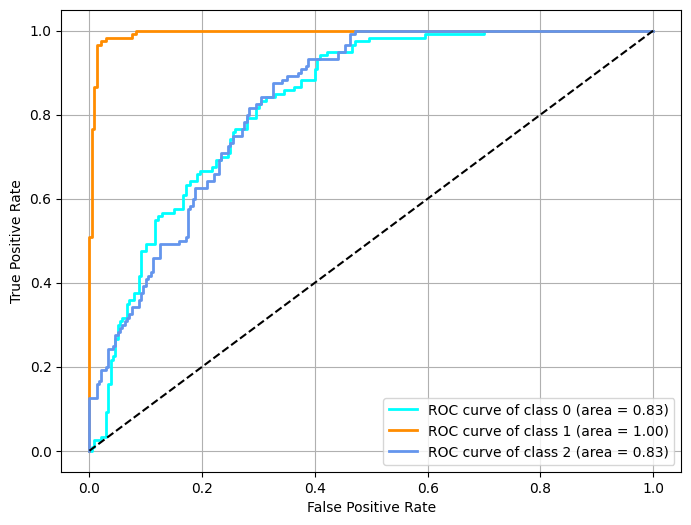


Updated MobileNetV2 Evaluation Metrics:
Accuracy: 0.7389
Precision: 0.7376
Recall (Sensitivity): 0.7389
Specificity: 0.8694
F1 Score: 0.7372
AUC: 0.8873
MCC: 0.6093
AUC (Macro): 0.8892
AUC (Micro): 0.91


In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np

# Use the predicted probabilities from your model
# y_pred_probs - predicted probabilities for each class
# y_true - true labels

n_classes = y_pred_probs.shape[1]

# Binarize the output for multiclass ROC
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 
                'purple', 'pink', 'brown', 'gray', 'olive'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Update metrics dictionary (example for VGG16, adjust for your model)
mobilenet_metrics['AUC (Macro)'] = round(roc_auc["macro"], 4)
mobilenet_metrics['AUC (Micro)'] = round(roc_auc["micro"], 4)

print("\nUpdated MobileNetV2 Evaluation Metrics:")
for key, value in mobilenet_metrics.items():
    print(f"{key}: {value}")


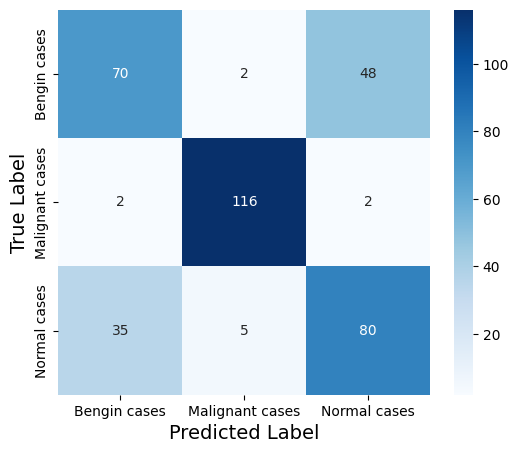

In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = list(train_gen.class_indices.keys())

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)

plt.title("", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()


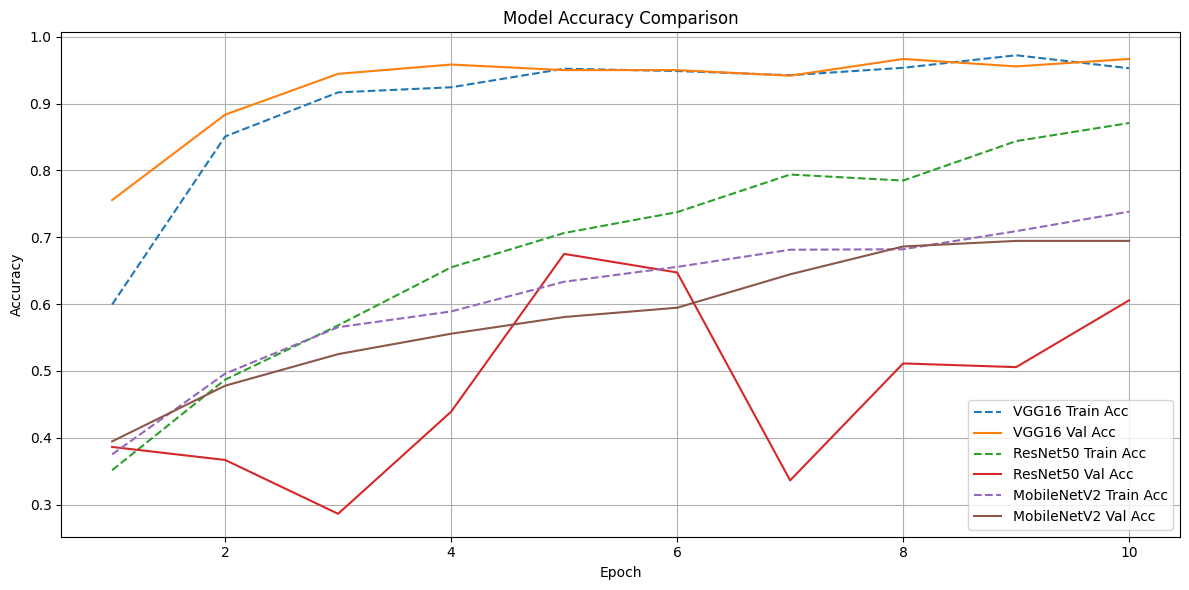

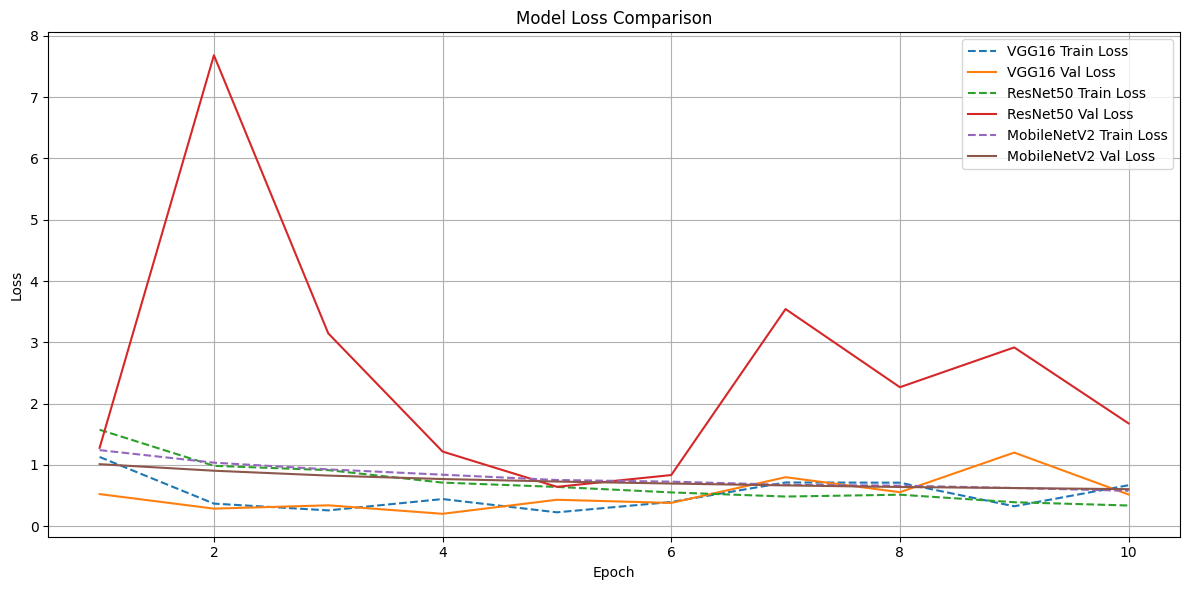

In [32]:
import matplotlib.pyplot as plt

# Epoch ranges
vgg_epochs = range(1, 11)
resnet_epochs = range(1, 11)
mobilenet_epochs = range(1, len(history.history['accuracy']) + 1)

# ACCURACY COMPARISON
plt.figure(figsize=(12, 6))
plt.plot(vgg_epochs, vgg_train_accuracies, '--', label='VGG16 Train Acc')
plt.plot(vgg_epochs, vgg_val_accuracies, label='VGG16 Val Acc')

plt.plot(resnet_epochs, rn_train_accuracies, '--', label='ResNet50 Train Acc')
plt.plot(resnet_epochs, rn_val_accuracies, label='ResNet50 Val Acc')

plt.plot(mobilenet_epochs, history.history['accuracy'], '--', label='MobileNetV2 Train Acc')
plt.plot(mobilenet_epochs, history.history['val_accuracy'], label='MobileNetV2 Val Acc')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# LOSS COMPARISON
plt.figure(figsize=(12, 6))
plt.plot(vgg_epochs, vgg_train_losses, '--', label='VGG16 Train Loss')
plt.plot(vgg_epochs, vgg_val_losses, label='VGG16 Val Loss')

plt.plot(resnet_epochs, rn_train_losses, '--', label='ResNet50 Train Loss')
plt.plot(resnet_epochs, rn_val_losses, label='ResNet50 Val Loss')

plt.plot(mobilenet_epochs, history.history['loss'], '--', label='MobileNetV2 Train Loss')
plt.plot(mobilenet_epochs, history.history['val_loss'], label='MobileNetV2 Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

